# INTRODUCTION
<br>
Klasifikasi penyakit jantung menggunakan beberapa metode machine learning algorithm.

In [1]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

## Read Data

In [28]:
# Load dataset
@st.cache_data
def load_data():
    df = pd.read_csv("assets/heart.csv")
    return df

df = load_data()

st.title("Preprocessing dan Prediksi Penyakit Jantung dengan SVC")

2025-03-25 16:09:09.657 No runtime found, using MemoryCacheStorageManager
2025-03-25 16:09:09.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:09:09.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [29]:
# Show raw data
st.subheader("Dataset Awal")
st.write(df.head())

2025-03-25 16:09:18.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:09:18.883 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:09:18.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:09:18.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [30]:
# Identifikasi kolom kategorikal
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

In [31]:
# OneHotEncoding
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))

In [32]:
# Gabungkan dengan kolom numerik
numeric_df = df.drop(columns=categorical_cols)
final_df = pd.concat([numeric_df, encoded_df], axis=1)

In [33]:
# Show processed data
st.subheader("Dataset Setelah OneHotEncoding")
st.write(final_df.head())

2025-03-25 16:09:44.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:09:44.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:09:44.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:09:44.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [35]:
# Pisahkan fitur dan target
y = final_df['HeartDisease']  # Asumsikan ada kolom 'target'
X = final_df.drop(columns=['HeartDisease'])


In [36]:
# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [38]:
# Train model
svc_model = SVC(kernel='linear', probability=True)
svc_model.fit(X_train, y_train)


SVC(kernel='linear', probability=True)

In [44]:
# Evaluasi model
y_pred = svc_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
st.subheader("Akurasi Model")
st.write(f"Akurasi Model pada Data Uji: {accuracy:.2f}")

2025-03-25 16:10:28.814 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:10:28.815 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:10:28.815 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:10:28.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:10:28.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-25 16:10:28.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


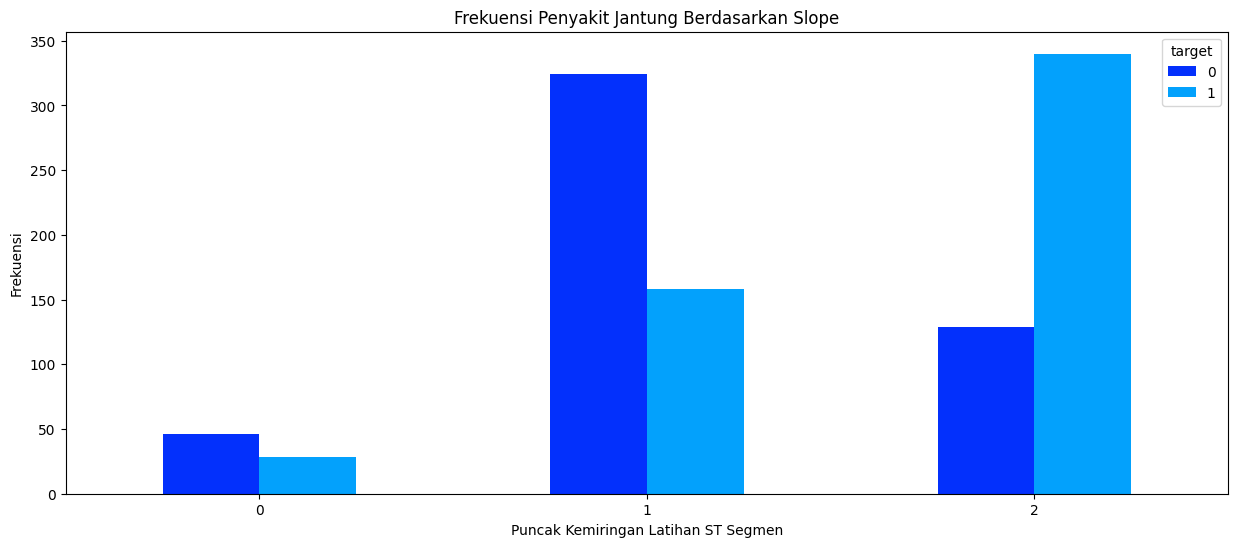

In [126]:
pd.crosstab(df.slope,df.target).plot(kind="bar",figsize=(15,6),color=['#0330fc','#03a1fc' ])
plt.title('Frekuensi Penyakit Jantung Berdasarkan Slope')
plt.xlabel('Puncak Kemiringan Latihan ST Segmen')
plt.xticks(rotation = 0)
plt.ylabel('Frekuensi')
plt.show()

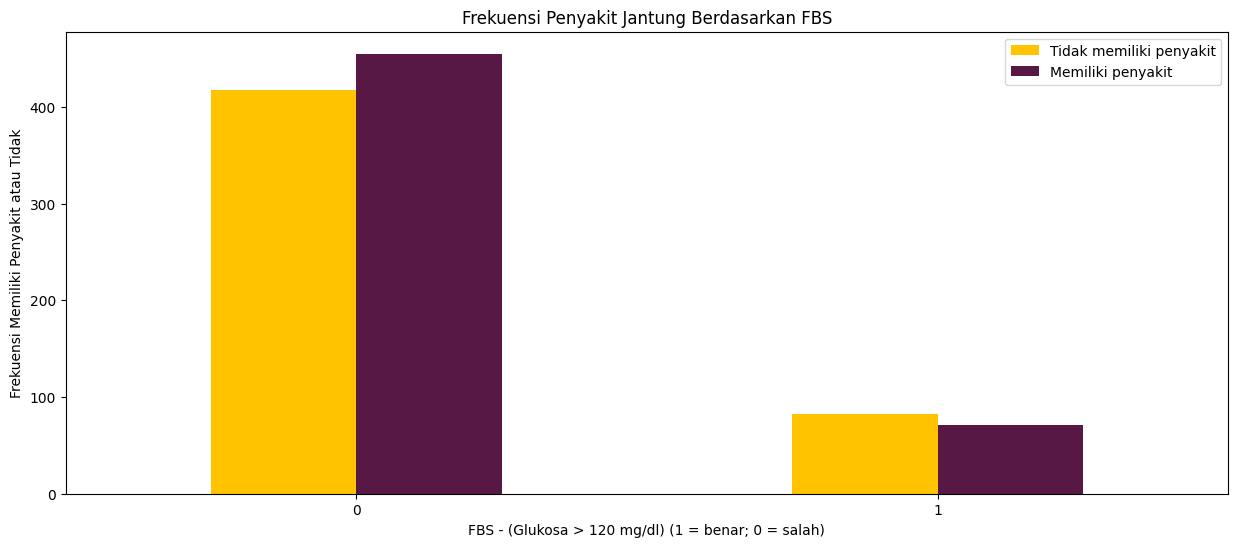

In [127]:
pd.crosstab(df.fbs,df.target).plot(kind="bar",figsize=(15,6),color=['#FFC300','#581845' ])
plt.title('Frekuensi Penyakit Jantung Berdasarkan FBS')
plt.xlabel('FBS - (Glukosa > 120 mg/dl) (1 = benar; 0 = salah)')
plt.xticks(rotation = 0)
plt.legend(["Tidak memiliki penyakit", "Memiliki penyakit"])
plt.ylabel('Frekuensi Memiliki Penyakit atau Tidak')
plt.show()

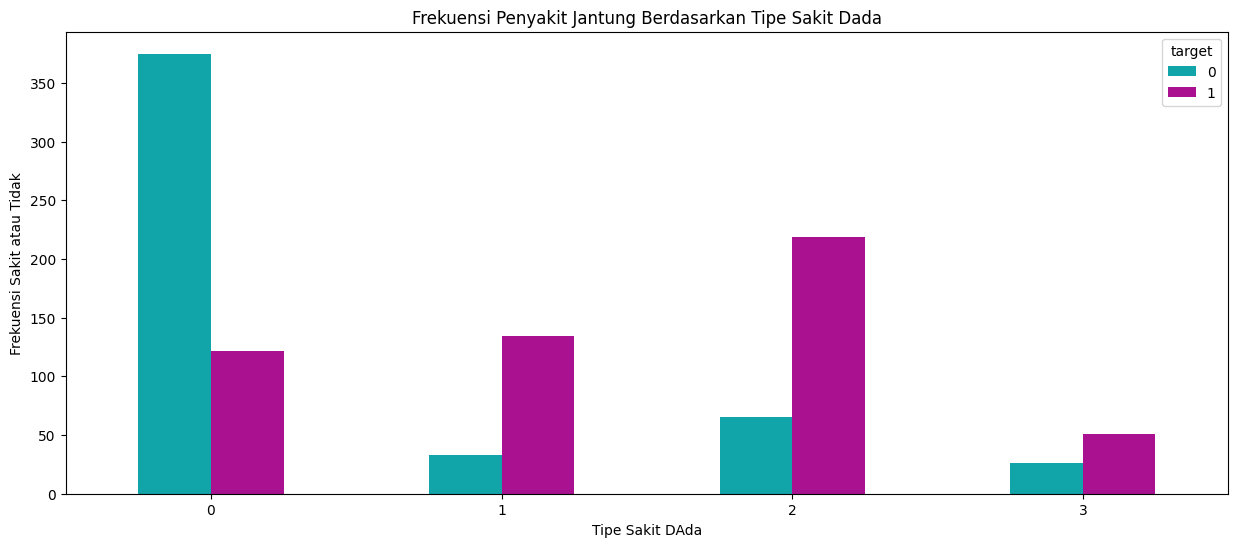

In [128]:
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(15,6),color=['#11A5AA','#AA1190' ])
plt.title('Frekuensi Penyakit Jantung Berdasarkan Tipe Sakit Dada')
plt.xlabel('Tipe Sakit DAda')
plt.xticks(rotation = 0)
plt.ylabel('Frekuensi Sakit atau Tidak')
plt.show()

### Membuat Dummy Variable

Dikarenakan 'cp', 'thal', 'slope' adalah kategorikal maka akan diubah ke numerik dengan menggunakan pandas dummies

In [129]:
a = pd.get_dummies(df['cp'], prefix = "cp", dtype=int)
b = pd.get_dummies(df['thal'], prefix = "thal", dtype=int)
c = pd.get_dummies(df['slope'], prefix = "slope", dtype=int)

In [130]:
frames = [df, a, b, c]
df = pd.concat(frames, axis = 1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,0,125,212,0,1,168,0,1.0,...,0,0,0,0,0,0,1,0,0,1
1,53,1,0,140,203,1,0,155,1,3.1,...,0,0,0,0,0,0,1,1,0,0
2,70,1,0,145,174,0,1,125,1,2.6,...,0,0,0,0,0,0,1,1,0,0
3,61,1,0,148,203,0,1,161,0,0.0,...,0,0,0,0,0,0,1,0,0,1
4,62,0,0,138,294,1,1,106,0,1.9,...,0,0,0,0,0,1,0,0,1,0


In [131]:
df = df.drop(columns = ['cp', 'thal', 'slope'])
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,125,212,0,1,168,0,1.0,2,...,0,0,0,0,0,0,1,0,0,1
1,53,1,140,203,1,0,155,1,3.1,0,...,0,0,0,0,0,0,1,1,0,0
2,70,1,145,174,0,1,125,1,2.6,0,...,0,0,0,0,0,0,1,1,0,0
3,61,1,148,203,0,1,161,0,0.0,1,...,0,0,0,0,0,0,1,0,0,1
4,62,0,138,294,1,1,106,0,1.9,3,...,0,0,0,0,0,1,0,0,1,0


## Membuat Model untuk Logistik Regression

Membuat function manual lalu menggunakan dari libraray sklearn

In [132]:
y = df.target.values
x_data = df.drop(['target'], axis = 1)

### Normalize Data
<br>
<br>
<img src="https://beyondbacktesting.files.wordpress.com/2017/07/normalization.png?w=863" width="400px"/>

In [133]:
# Normalisasi Data
x = (x_data - x_data.min()) / (x_data.max() - x_data.min()).values

Split data 70% dan 30% untuk testing

In [134]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3,random_state=42)

In [135]:
# Transpose Matriks
x_train = x_train.T
y_train = y_train.T
x_test = x_test.T
y_test = y_test.T

Katakanlah bobot = 0.1 and bias = 1

In [136]:
#initialize
def initialize(dimension):

    weight = np.full((dimension,1),0.1)
    bias = 1
    return weight,bias

### Sigmoid Function

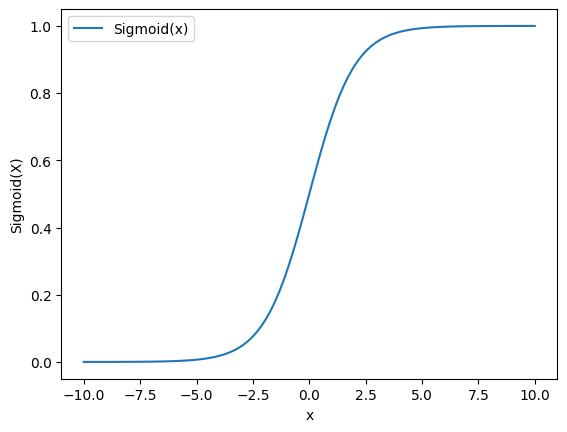

In [137]:
import matplotlib.pyplot as plt
import numpy as np
import math

x = np.linspace(-10, 10, 100)
z = 1/(1 + np.exp(-x))

plt.plot(x, z, label='Sigmoid(x)')
plt.xlabel("x")
plt.ylabel("Sigmoid(X)")
plt.legend()

In [138]:
def sigmoid(z):

    y_head = 1/(1+ np.exp(-z))
    return y_head

### Forward and Backward Propagation
<br>
<img src="https://image.slidesharecdn.com/gradientdescentbackpropandautomaticdifferentiation-160829164205/95/gradient-descent-back-propagation-and-auto-differentiation-advanced-spark-and-tensorflow-meetup-08042016-62-638.jpg?cb=1472489358" width="500px"/>

### Cost Function
<br>
<img src="https://i.stack.imgur.com/XbU4S.png" width="500px"/>

### Gradient Descent
<br>
<img src="https://i.stack.imgur.com/pYVzl.png" width="500px"/>


* h0(x^i)= y_head
* y^i = y_train
* x^i = x_train

In [139]:
def forwardBackward(weight,bias,x_train,y_train):
    # Forward

    y_head = sigmoid(np.dot(weight.T,x_train) + bias)
    loss = -(y_train*np.log(y_head) + (1-y_train)*np.log(1-y_head))
    cost = np.sum(loss) / x_train.shape[1]

    # Backward
    derivative_weight = np.dot(x_train,((y_head-y_train).T))/x_train.shape[1]
    derivative_bias = np.sum(y_head-y_train)/x_train.shape[1]
    gradients = {"Derivative Weight" : derivative_weight, "Derivative Bias" : derivative_bias}

    return cost,gradients

In [140]:
def update(weight,bias,x_train,y_train,learningRate,iteration) :
    costList = []
    index = []

    #for each iteration, update weight and bias values
    for i in range(iteration):
        cost,gradients = forwardBackward(weight,bias,x_train,y_train)
        weight = weight - learningRate * gradients["Derivative Weight"]
        bias = bias - learningRate * gradients["Derivative Bias"]

        costList.append(cost)
        index.append(i)

    parameters = {"weight": weight,"bias": bias}

    print("iteration:",iteration)
    print("cost:",cost)

    plt.plot(index,costList)
    plt.xlabel("Number of Iteration")
    plt.ylabel("Cost")
    plt.show()

    return parameters, gradients

In [141]:
def predict(weight,bias,x_test):
    z = np.dot(weight.T,x_test) + bias
    y_head = sigmoid(z)

    y_prediction = np.zeros((1,x_test.shape[1]))

    for i in range(y_head.shape[1]):
        if y_head[0,i] <= 0.5:
            y_prediction[0,i] = 0
        else:
            y_prediction[0,i] = 1
    return y_prediction

## Support Vector Machine (SVM) Algorithm

**Support Vector Machine Algorithm**
<br>
<img src="https://cdn-images-1.medium.com/max/1600/1*TudH6YvvH7-h5ZyF2dJV2w.jpeg" width="500px"/><br>
<img src="https://aitrends.com/wp-content/uploads/2018/01/1-19SVM-2.jpg" width="500px"/>


In [144]:
from sklearn.svm import SVC

In [ ]:
svm = SVC(random_state = 1)
svm.fit(x_train.T, y_train.T)

acc = svm.score(x_test.T,y_test.T)*100
accuracy['SVM'] = acc
print(f"Test Akurasi SVM: {round(acc, 2)}%")

Test Akurasi SVM: 86.04%


## <font color="orange">Test Accuracy of SVM Algorithm is <font color="red"> 86.04%</font></font>